Baseline set (h = 0.01)

h = 0.5
Total accumulated error = 3.9538831398157264

h = 1
Total accumulated error = 10.3967225856

h = 1.5
Total accumulated error = 126.327936


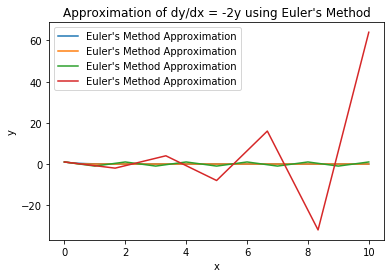

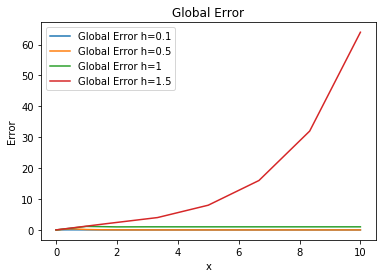

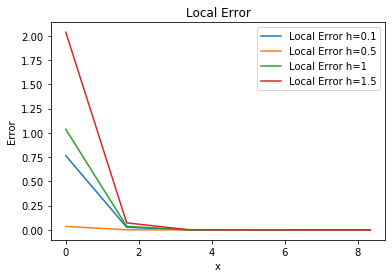

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h_values = [0.1,0.5,1,1.5]  # step size
x_start, x_end = 0, 10

# Was getting an error with my plot, so ChatGPT suggested using baseline
baseline_y = None

def exact(x):
    return np.exp(-2*x)

plt.figure()

for h in h_values:

    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    # Exact Values
    y_exact = exact(x_values)
    
    # Global Error
    global_err = abs(y_exact - y_values)
    
    # Local Error - Followed off given Euler's Method
    local_error = []
    for i in range(num_steps):
        y_exact_i = y_exact[i]
        y_euler_step = y_exact_i + h * f(x_values[i], y_exact_i)
        y_exact_next = y_exact[i + 1]
        error = abs(y_exact_next - y_euler_step)
        local_error.append(error)
    
   # Asked ChatGPT for help on how to calculate accumulated error
    if baseline_y is None:
        baseline_y = y_values
        print("Baseline set (h = 0.01)")
    else:
        n = min(len(y_values), len(baseline_y))
        error = abs(y_values[:n] - baseline_y[:n])
        total_error = sum(error)

        print("\nh =", h)
        print("Total accumulated error =", total_error)
        
    plt.plot(x_values, y_values, label="Euler's Method Approximation")    

# Plot the results
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

plt.figure()

# Plot Global Error
for h in h_values:

    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    y_exact = exact(x_values)
    global_error = abs(y_exact - y_values)
    
    plt.plot(x_values, global_error, label=f"Global Error h={h}")

plt.xlabel('x')
plt.ylabel('Error')
plt.title("Global Error")
plt.legend()
plt.show()

# Plot Local Error
plt.figure()

for h in h_values:

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_exact = exact(x_values)

    local_error = []

    for i in range(num_steps):
        y_step = y_exact[i] + h * (-2 * y_exact[i])
        error = abs(y_exact[i+1] - y_step)
        local_error.append(error)
        
    plt.plot(x_values[:-1], local_error, label=f"Local Error h={h}")

plt.xlabel('x')
plt.ylabel('Error')
plt.title("Local Error")
plt.legend()
plt.show()

# Ran my code through ChatGPT to ensure there were no errors and satisfied what challenge was asking for